# Daily Challenge - Statistics for Machine Learning


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")
matplotlib.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv('churn_modelling.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

df_0 = df[df['Exited'] == 0]  # Customers who stayed
df_1 = df[df['Exited'] == 1]  # Customers who left

print("\nClass Distribution:")
print(df['Exited'].value_counts(normalize=True).round(3) * 100)

Dataset Overview:
Shape: (10000, 14)

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57 

## Hypothesis 1: Age Analysis

H₀: Age distributions are similar between churned and non-churned customers  
H₁: Age distributions are different between churned and non-churned customers

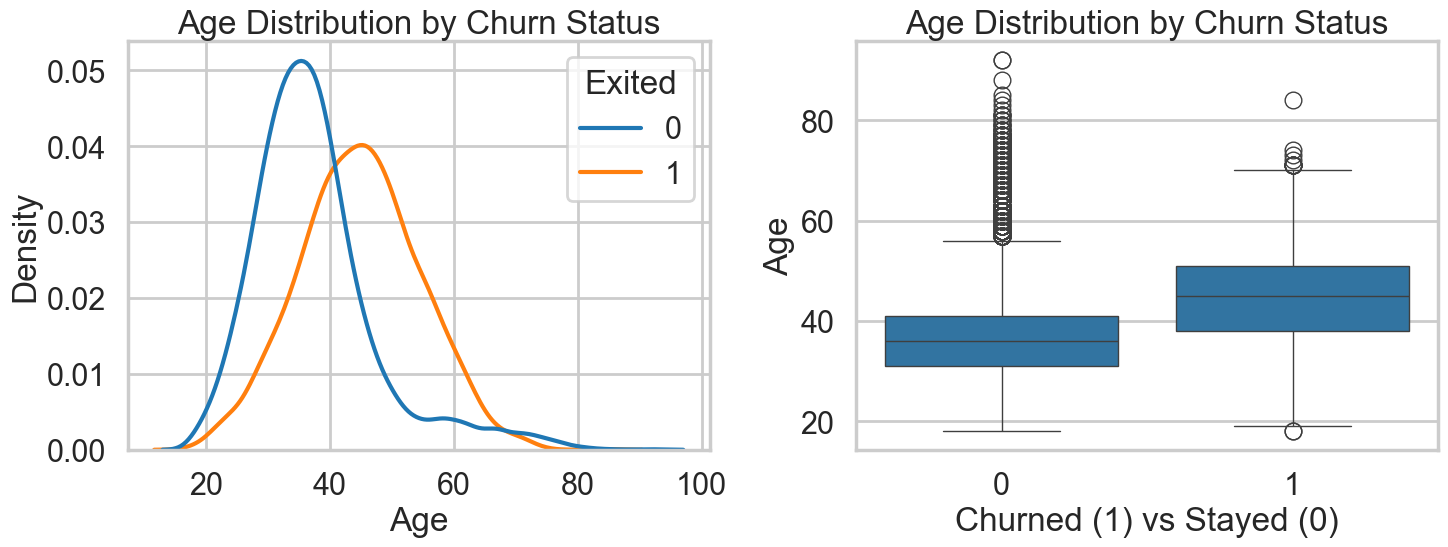

Age Statistics:

Stayed with bank:
Mean: 37.41
Std: 10.13

Left bank:
Mean: 44.84
Std: 9.76

t-statistic: -29.7668
p-value: 1.2399e-186

Bootstrap p-value: 5.0250e-01

Bootstrap p-value: 5.0250e-01


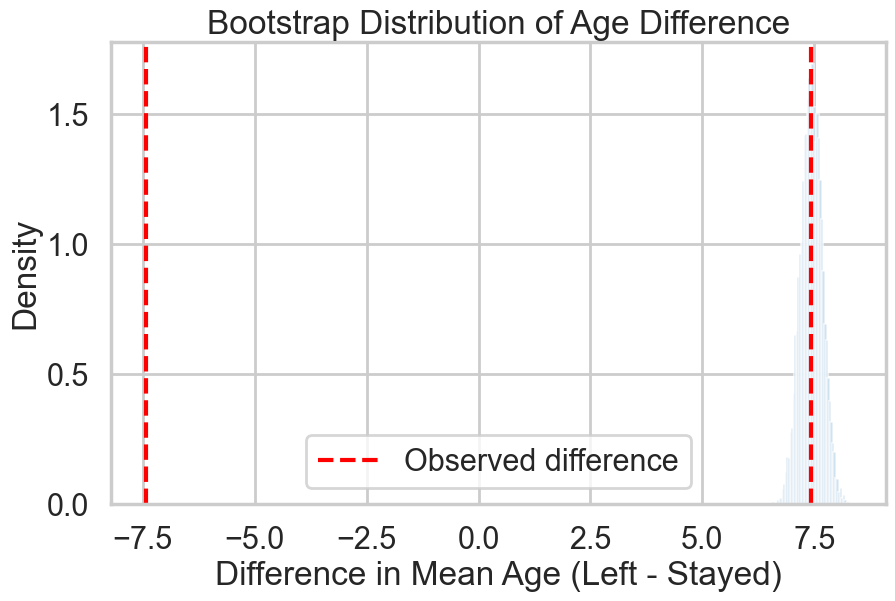

In [6]:
# Visualize age distribution by churn status
plt.figure(figsize=(15, 6))

# Plot 1: Distribution plot
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Age', hue='Exited', common_norm=False)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Density')

# Plot 2: Box plot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Churned (1) vs Stayed (0)')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

# Calculate statistics
print("Age Statistics:")
print("\nStayed with bank:")
print(f"Mean: {df_0['Age'].mean():.2f}")
print(f"Std: {df_0['Age'].std():.2f}")

print("\nLeft bank:")
print(f"Mean: {df_1['Age'].mean():.2f}")
print(f"Std: {df_1['Age'].std():.2f}")

# Perform t-test
t_stat, p_value = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

# Bootstrap analysis
def bs_choice(data, func, size=10000):
    bs_stats = np.zeros(size)
    for i in range(size):
        bs_sample = np.random.choice(data, size=len(data), replace=True)
        bs_stats[i] = func(bs_sample)
    return bs_stats

# Calculate bootstrap distributions
bs_stayed = bs_choice(df_0['Age'], np.mean)
bs_left = bs_choice(df_1['Age'], np.mean)
bs_diff = bs_left - bs_stayed

# Calculate bootstrap p-value
observed_diff = df_1['Age'].mean() - df_0['Age'].mean()
bs_p_value = np.mean(np.abs(bs_diff) >= np.abs(observed_diff))

print(f"\nBootstrap p-value: {bs_p_value:.4e}")

# Visualize bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(bs_diff, bins=50, density=True, alpha=0.7)
plt.axvline(observed_diff, color='red', linestyle='--', label='Observed difference')
plt.axvline(-observed_diff, color='red', linestyle='--')
plt.title('Bootstrap Distribution of Age Difference')
plt.xlabel('Difference in Mean Age (Left - Stayed)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Hypothesis 2: Credit Score Analysis

H₀: Credit Score distributions are similar between churned and non-churned customers  
H₁: Credit Score distributions are different between churned and non-churned customers

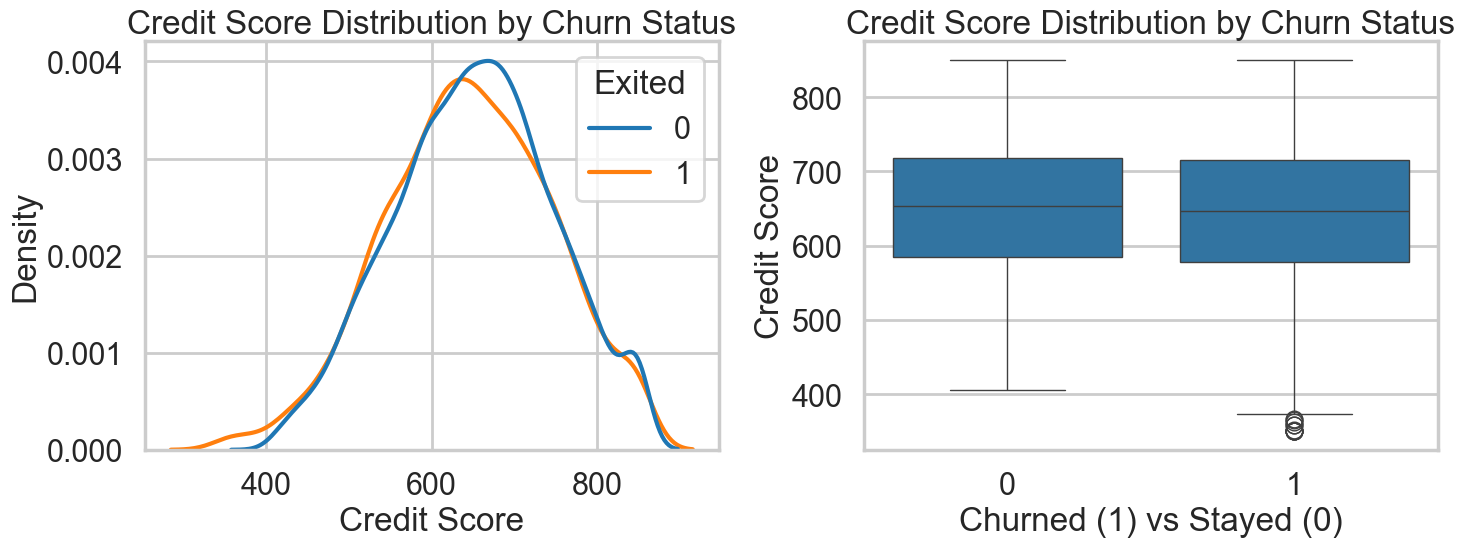

Credit Score Statistics:

Stayed with bank:
Mean: 651.85
Std: 95.65

Left bank:
Mean: 645.35
Std: 100.32

t-statistic: 2.7101
p-value: 6.7382e-03


In [7]:
# Visualize Credit Score distribution
plt.figure(figsize=(15, 6))

# Plot 1: Distribution plot
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='CreditScore', hue='Exited', common_norm=False)
plt.title('Credit Score Distribution by Churn Status')
plt.xlabel('Credit Score')
plt.ylabel('Density')

# Plot 2: Box plot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='CreditScore')
plt.title('Credit Score Distribution by Churn Status')
plt.xlabel('Churned (1) vs Stayed (0)')
plt.ylabel('Credit Score')

plt.tight_layout()
plt.show()

# Calculate statistics
print("Credit Score Statistics:")
print("\nStayed with bank:")
print(f"Mean: {df_0['CreditScore'].mean():.2f}")
print(f"Std: {df_0['CreditScore'].std():.2f}")

print("\nLeft bank:")
print(f"Mean: {df_1['CreditScore'].mean():.2f}")
print(f"Std: {df_1['CreditScore'].std():.2f}")

# Perform t-test
t_stat, p_value = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

## Hypothesis 3: Balance Analysis

H₀: Balance distributions are similar between churned and non-churned customers  
H₁: Balance distributions are different between churned and non-churned customers

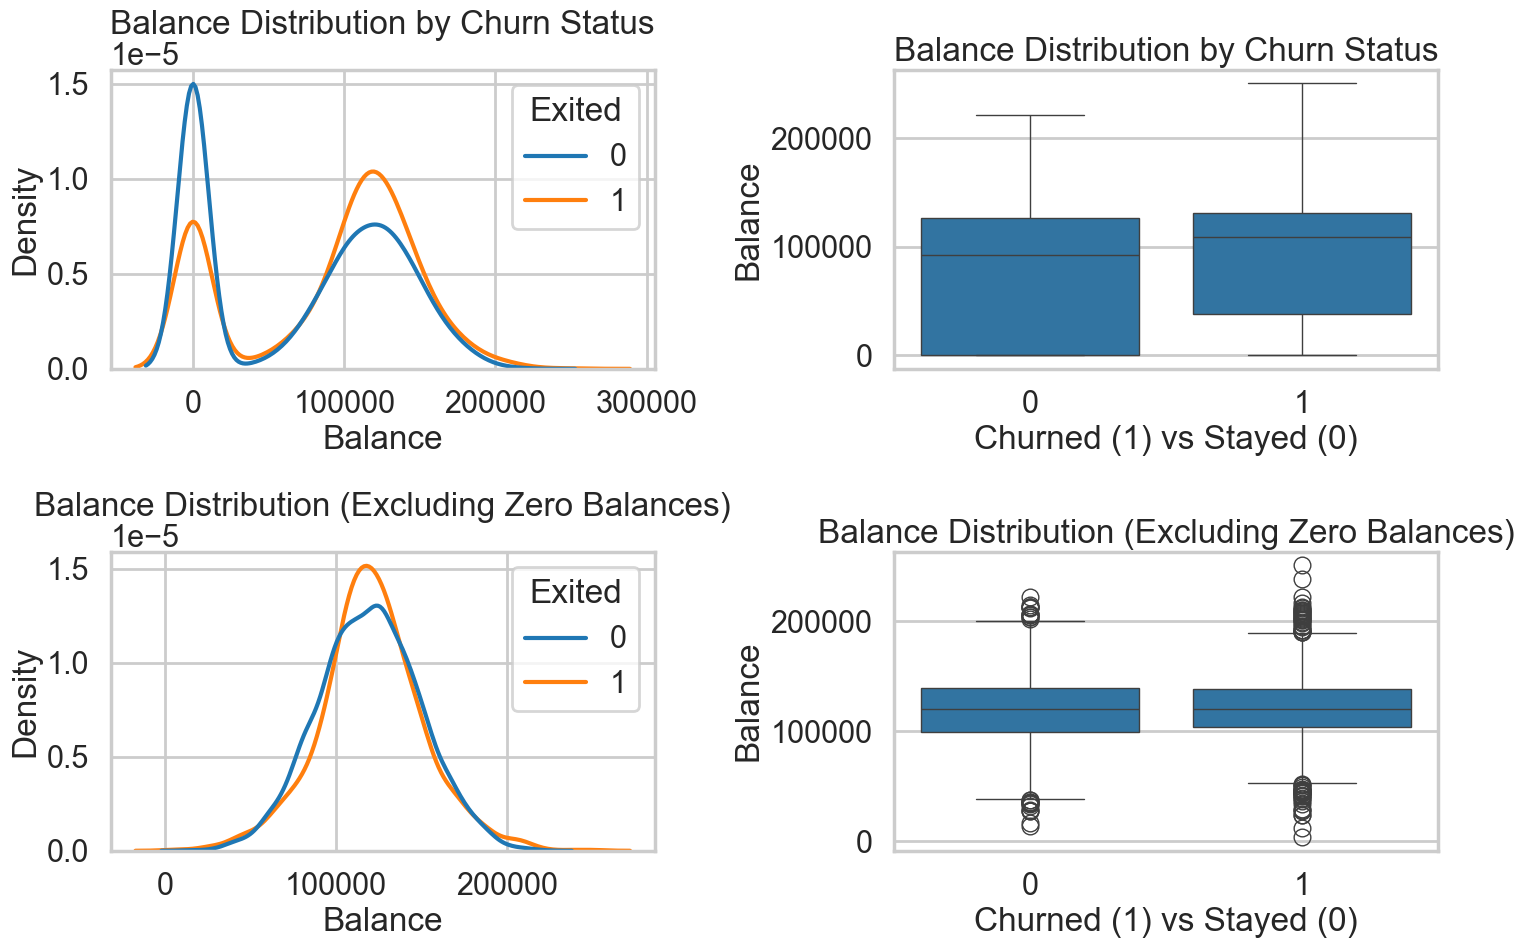

Balance Statistics:

All accounts:
Stayed with bank:
Mean: 72745.30
Std: 62848.04

Left bank:
Mean: 91108.54
Std: 58360.79

Non-zero balance accounts:
Stayed with bank:
Mean: 119535.86
Std: 29944.93

Left bank:
Mean: 120746.97
Std: 30555.19

t-test results (all accounts):
t-statistic: -11.9362
p-value: 1.2756e-32

t-test results (non-zero balance accounts):
t-statistic: -1.3748
p-value: 1.6925e-01


In [8]:
# Visualize Balance distribution
plt.figure(figsize=(15, 10))

# Plot 1: Full distribution
plt.subplot(2, 2, 1)
sns.kdeplot(data=df, x='Balance', hue='Exited', common_norm=False)
plt.title('Balance Distribution by Churn Status')
plt.xlabel('Balance')
plt.ylabel('Density')

# Plot 2: Box plot
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Exited', y='Balance')
plt.title('Balance Distribution by Churn Status')
plt.xlabel('Churned (1) vs Stayed (0)')
plt.ylabel('Balance')

# Plot 3: Distribution excluding zero balances
plt.subplot(2, 2, 3)
df_nonzero = df[df['Balance'] > 0]
sns.kdeplot(data=df_nonzero, x='Balance', hue='Exited', common_norm=False)
plt.title('Balance Distribution (Excluding Zero Balances)')
plt.xlabel('Balance')
plt.ylabel('Density')

# Plot 4: Box plot excluding zero balances
plt.subplot(2, 2, 4)
sns.boxplot(data=df_nonzero, x='Exited', y='Balance')
plt.title('Balance Distribution (Excluding Zero Balances)')
plt.xlabel('Churned (1) vs Stayed (0)')
plt.ylabel('Balance')

plt.tight_layout()
plt.show()

# Calculate statistics
print("Balance Statistics:")
print("\nAll accounts:")
print("Stayed with bank:")
print(f"Mean: {df_0['Balance'].mean():.2f}")
print(f"Std: {df_0['Balance'].std():.2f}")
print("\nLeft bank:")
print(f"Mean: {df_1['Balance'].mean():.2f}")
print(f"Std: {df_1['Balance'].std():.2f}")

print("\nNon-zero balance accounts:")
print("Stayed with bank:")
print(f"Mean: {df_0[df_0['Balance'] > 0]['Balance'].mean():.2f}")
print(f"Std: {df_0[df_0['Balance'] > 0]['Balance'].std():.2f}")
print("\nLeft bank:")
print(f"Mean: {df_1[df_1['Balance'] > 0]['Balance'].mean():.2f}")
print(f"Std: {df_1[df_1['Balance'] > 0]['Balance'].std():.2f}")

# Perform t-tests
# All accounts
t_stat, p_value = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print(f"\nt-test results (all accounts):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

# Non-zero balance accounts
t_stat, p_value = scipy.stats.ttest_ind(
    df_0[df_0['Balance'] > 0]['Balance'],
    df_1[df_1['Balance'] > 0]['Balance']
)
print(f"\nt-test results (non-zero balance accounts):")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

## Hypothesis 4: Estimated Salary Analysis

H₀: Estimated Salary distributions are similar between churned and non-churned customers  
H₁: Estimated Salary distributions are different between churned and non-churned customers

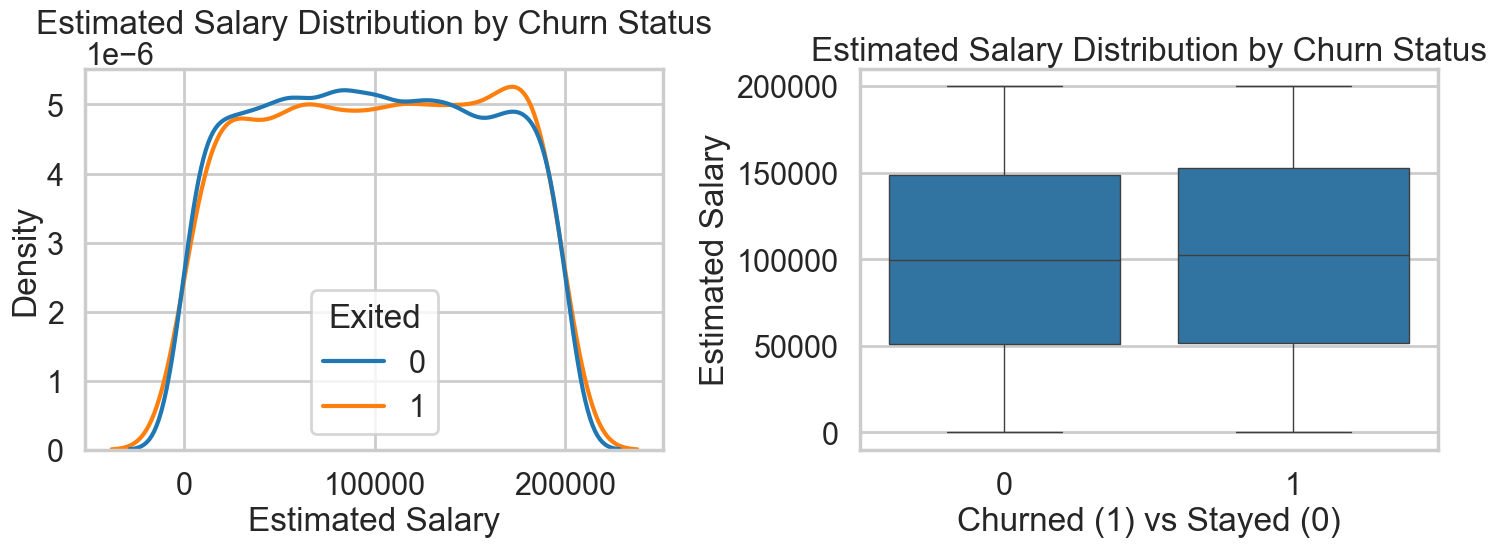

Estimated Salary Statistics:

Stayed with bank:
Mean: 99738.39
Std: 57405.59

Left bank:
Mean: 101465.68
Std: 57912.42

t-statistic: -1.2097
p-value: 2.2644e-01

Bootstrap p-value: 5.1090e-01

Bootstrap p-value: 5.1090e-01


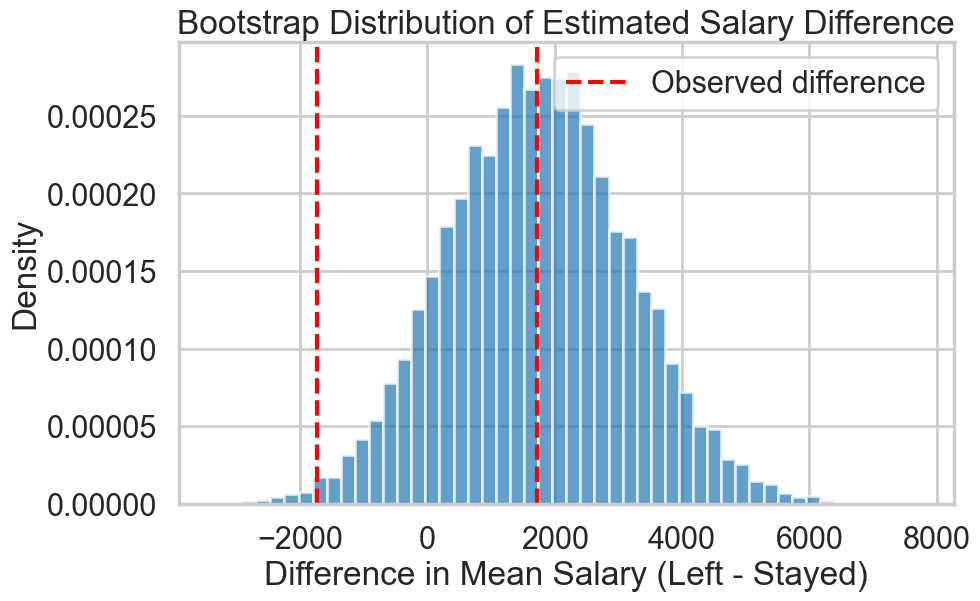

In [9]:
# Visualize Estimated Salary distribution
plt.figure(figsize=(15, 6))

# Plot 1: Distribution plot
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='EstimatedSalary', hue='Exited', common_norm=False)
plt.title('Estimated Salary Distribution by Churn Status')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')

# Plot 2: Box plot
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='EstimatedSalary')
plt.title('Estimated Salary Distribution by Churn Status')
plt.xlabel('Churned (1) vs Stayed (0)')
plt.ylabel('Estimated Salary')

plt.tight_layout()
plt.show()

# Calculate statistics
print("Estimated Salary Statistics:")
print("\nStayed with bank:")
print(f"Mean: {df_0['EstimatedSalary'].mean():.2f}")
print(f"Std: {df_0['EstimatedSalary'].std():.2f}")

print("\nLeft bank:")
print(f"Mean: {df_1['EstimatedSalary'].mean():.2f}")
print(f"Std: {df_1['EstimatedSalary'].std():.2f}")

# Perform t-test
t_stat, p_value = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")

# Bootstrap analysis
bs_stayed = bs_choice(df_0['EstimatedSalary'], np.mean)
bs_left = bs_choice(df_1['EstimatedSalary'], np.mean)
bs_diff = bs_left - bs_stayed

# Calculate bootstrap p-value
observed_diff = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()
bs_p_value = np.mean(np.abs(bs_diff) >= np.abs(observed_diff))

print(f"\nBootstrap p-value: {bs_p_value:.4e}")

# Visualize bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(bs_diff, bins=50, density=True, alpha=0.7)
plt.axvline(observed_diff, color='red', linestyle='--', label='Observed difference')
plt.axvline(-observed_diff, color='red', linestyle='--')
plt.title('Bootstrap Distribution of Estimated Salary Difference')
plt.xlabel('Difference in Mean Salary (Left - Stayed)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Final Conclusions and Feature Importance

Let's analyze the significance and predictive power of each feature:

Feature Importance Summary:
                 Effect Size        P-value
Age                 0.739092  1.239931e-186
Balance             0.296370   1.275563e-32
CreditScore         0.067290   6.738214e-03
EstimatedSalary     0.030035   2.264404e-01

Effect Size Interpretation:
0.2: Small effect
0.5: Medium effect
0.8: Large effect


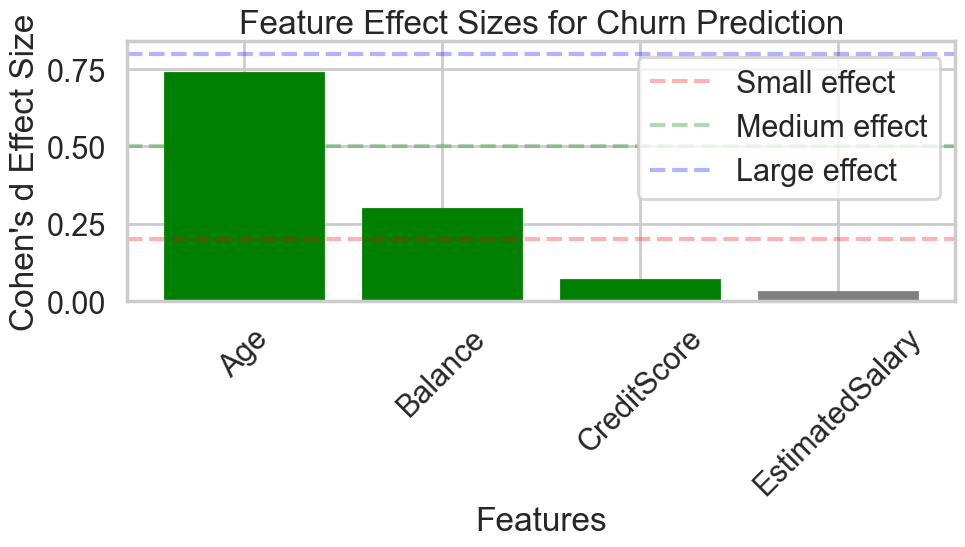


Final Conclusions:

Age:
- Statistically significant (p = 1.2399e-186)
- Medium effect size (d = 0.739)

Balance:
- Statistically significant (p = 1.2756e-32)
- Small effect size (d = 0.296)

CreditScore:
- Statistically significant (p = 6.7382e-03)
- Small effect size (d = 0.067)

EstimatedSalary:
- Not statistically significant (p = 2.2644e-01)
- Small effect size (d = 0.030)


In [10]:
# Calculate effect sizes (Cohen's d) for each feature
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_se = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_se

features = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']
effect_sizes = {}
p_values = {}

for feature in features:
    # Calculate effect size
    effect_size = cohens_d(df_0[feature], df_1[feature])
    effect_sizes[feature] = abs(effect_size)
    
    # Calculate p-value
    _, p_val = scipy.stats.ttest_ind(df_0[feature], df_1[feature])
    p_values[feature] = p_val

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Effect Size': effect_sizes,
    'P-value': p_values
})

summary_df = summary_df.sort_values('Effect Size', ascending=False)

print("Feature Importance Summary:")
print("=" * 50)
print(summary_df)
print("\nEffect Size Interpretation:")
print("0.2: Small effect")
print("0.5: Medium effect")
print("0.8: Large effect")

# Visualize effect sizes
plt.figure(figsize=(10, 6))
bars = plt.bar(summary_df.index, summary_df['Effect Size'])
plt.axhline(y=0.2, color='r', linestyle='--', alpha=0.3, label='Small effect')
plt.axhline(y=0.5, color='g', linestyle='--', alpha=0.3, label='Medium effect')
plt.axhline(y=0.8, color='b', linestyle='--', alpha=0.3, label='Large effect')

# Color bars based on statistical significance
for i, p_value in enumerate(summary_df['P-value']):
    if p_value < 0.05:
        bars[i].set_color('green')
    else:
        bars[i].set_color('gray')

plt.title('Feature Effect Sizes for Churn Prediction')
plt.xlabel('Features')
plt.ylabel("Cohen's d Effect Size")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("\nFinal Conclusions:")
print("=" * 50)
for feature in summary_df.index:
    effect = summary_df.loc[feature, 'Effect Size']
    p_val = summary_df.loc[feature, 'P-value']
    
    if p_val < 0.05:
        significance = "Statistically significant"
    else:
        significance = "Not statistically significant"
        
    if effect >= 0.8:
        effect_size = "large"
    elif effect >= 0.5:
        effect_size = "medium"
    else:
        effect_size = "small"
        
    print(f"\n{feature}:")
    print(f"- {significance} (p = {p_val:.4e})")
    print(f"- {effect_size.capitalize()} effect size (d = {effect:.3f})")